![New York City schoolbus](schoolbus.jpg)

Photo by [Jannis Lucas](https://unsplash.com/@jannis_lucas) on [Unsplash](https://unsplash.com).
<br>

Every year, American high school students take SATs, which are standardized tests intended to measure literacy, numeracy, and writing skills. There are three sections - reading, math, and writing, each with a **maximum score of 800 points**. These tests are extremely important for students and colleges, as they play a pivotal role in the admissions process.

Analyzing the performance of schools is important for a variety of stakeholders, including policy and education professionals, researchers, government, and even parents considering which school their children should attend. 

You have been provided with a dataset called `schools.csv`, which is previewed below.

You have been tasked with answering three key questions about New York City (NYC) public school SAT performance.

add cells

## Exploring NYC Public School SAT Performance

Let's begin our analysis of SAT performance in New York City public schools using the provided `schools.csv` dataset. We will answer three key questions:

1. **How does SAT performance vary by borough?**
2. **Which borough has the most variation in SAT scores among its schools?**
3. **How are the different SAT sections (math, reading, writing) related to each other?**

We have already loaded and prepared the data. Let's start by examining SAT performance by borough.

In [29]:
import pandas as pd
# Read in the data
schools = pd.read_csv("schools.csv")

# 1. Which NYC schools have the best math results?
# 80% of 800 is 640. Filter for these schools, select columns, and sort descending.
best_math_schools = schools[schools['average_math'] >= 640][['school_name', 'average_math']].sort_values('average_math', ascending=False)

# 2. What are the top 10 performing schools based on the combined SAT scores?
# Create 'total_SAT', select columns, sort descending, and get the top 10.
schools['total_SAT'] = schools['average_math'] + schools['average_reading'] + schools['average_writing']
top_10_schools = schools[['school_name', 'total_SAT']].sort_values('total_SAT', ascending=False).head(10)


# 3. Which single borough has the largest standard deviation in the combined SAT score?
# Group by borough, calculate requested metrics, and round to 2 decimal places
borough_stats = schools.groupby('borough')['total_SAT'].agg(['count', 'mean', 'std']).round(2)

# Rename columns to match the exact project requirements
borough_stats = borough_stats.rename(columns={'count': 'num_schools', 'mean': 'average_SAT', 'std': 'std_SAT'})

# Find the maximum standard deviation, filter for that row, and reset the index so 'borough' becomes a column
largest_std_dev = borough_stats[borough_stats['std_SAT'] == borough_stats['std_SAT'].max()].reset_index()

# Display the final required output
display(largest_std_dev)

,borough,num_schools,average_SAT,std_SAT
0,Manhattan,89,1340.13,230.29


# Correlation Between SAT Sections
A correlation matrix quantifies the exact linear relationships between the different SAT sections. By isolating the math, reading, and writing columns and applying the pandas .corr() method, we generate a clean tabular summary that reveals how strongly performance in one subject aligns with the others before visualizing those trends in a heatmap.

--- Correlation Matrix Table ---


,average_math,average_reading,average_writing
average_math,1.000000,0.928239,0.934155
average_reading,0.928239,1.000000,0.985439
average_writing,0.934155,0.985439,1.000000


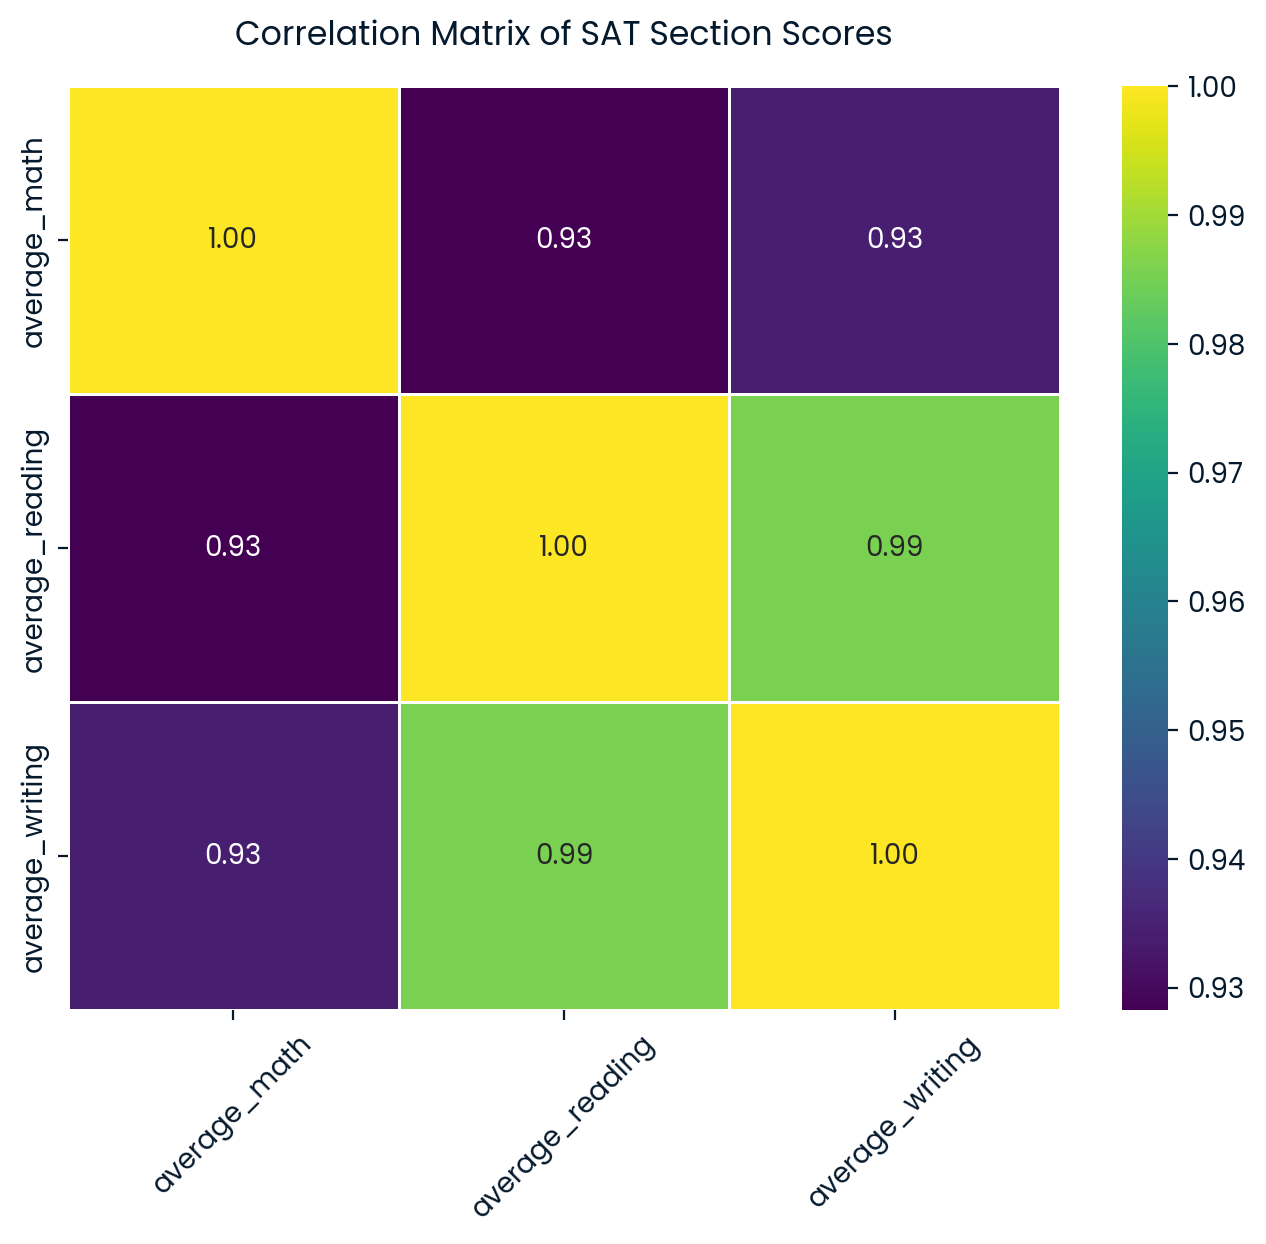

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the specific SAT section columns
sat_columns = schools[['average_math', 'average_reading', 'average_writing']]

# Calculate the correlation matrix
correlation_matrix = sat_columns.corr()

# Display the correlation matrix as a table
print("--- Correlation Matrix Table ---")
display(correlation_matrix)

# Plot a heatmap of the correlation matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of SAT Section Scores", pad=15)
plt.xticks(rotation=45)
plt.show()

# Correlation Between Math and Reading
The scatter plot above reveals the relationship between math and reading performance. Adding a trendline helps determine if schools excelling in quantitative skills also excel in literacy.

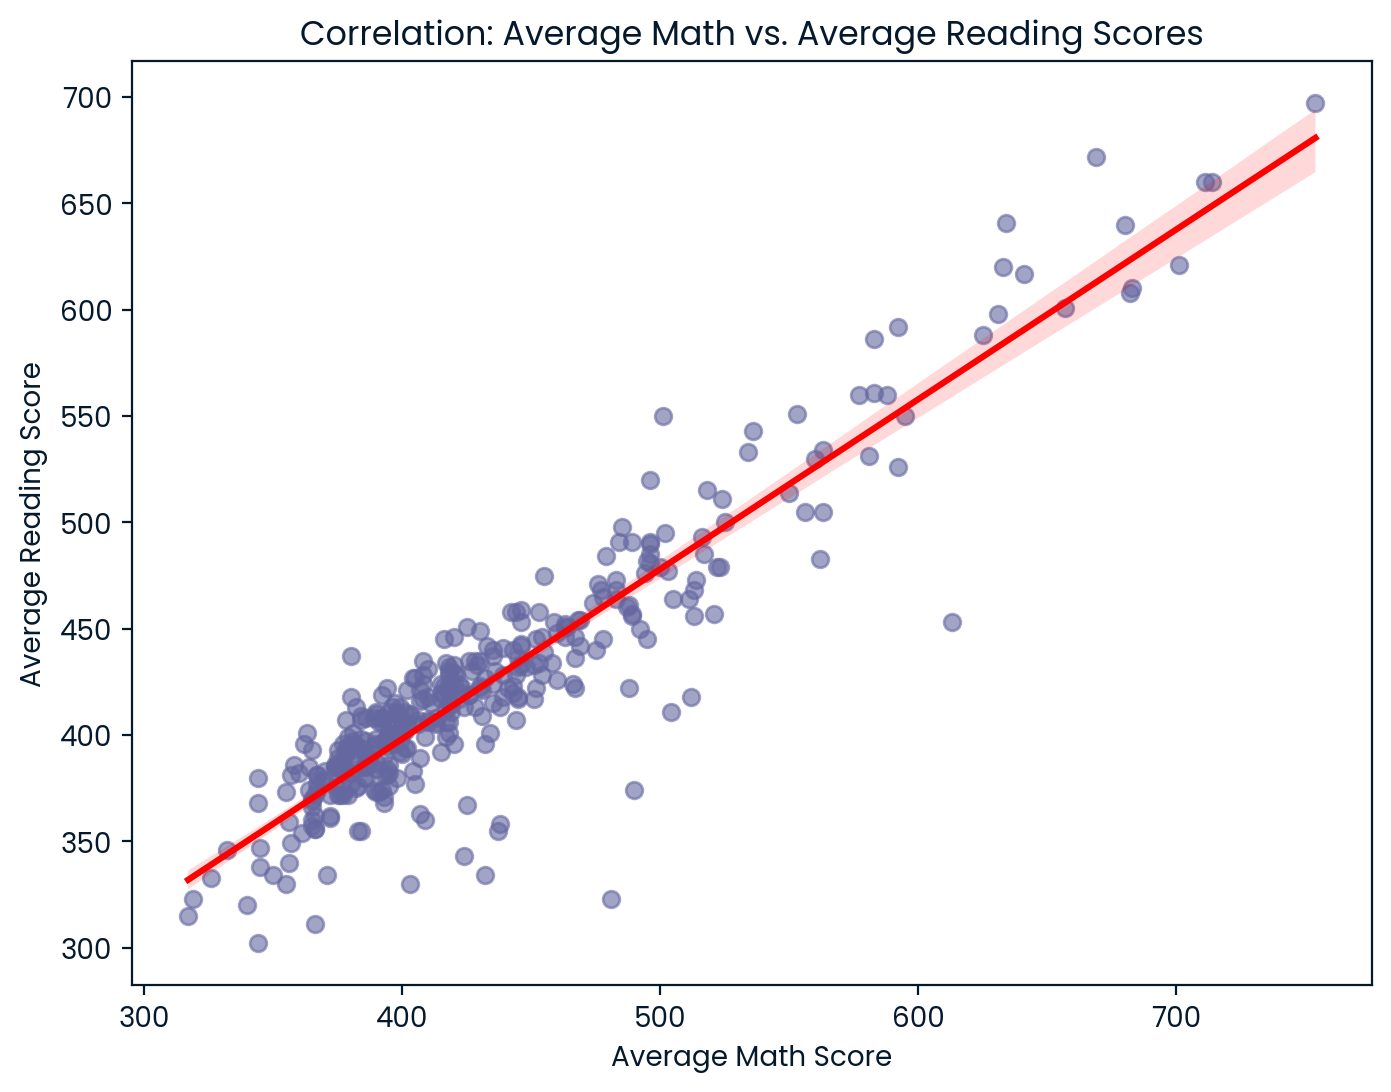

In [9]:
plt.figure(figsize=(8, 6))
sns.regplot(data=schools, x='average_math', y='average_reading', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlation: Average Math vs. Average Reading Scores')
plt.xlabel('Average Math Score')
plt.ylabel('Average Reading Score')
plt.show()

# Visualizing the Top 10 Schools
Converting your top_10_schools DataFrame into a horizontal bar chart makes the ranking instantly readable and emphasizes the score gaps between the highest-performing institutions.

add empty cell

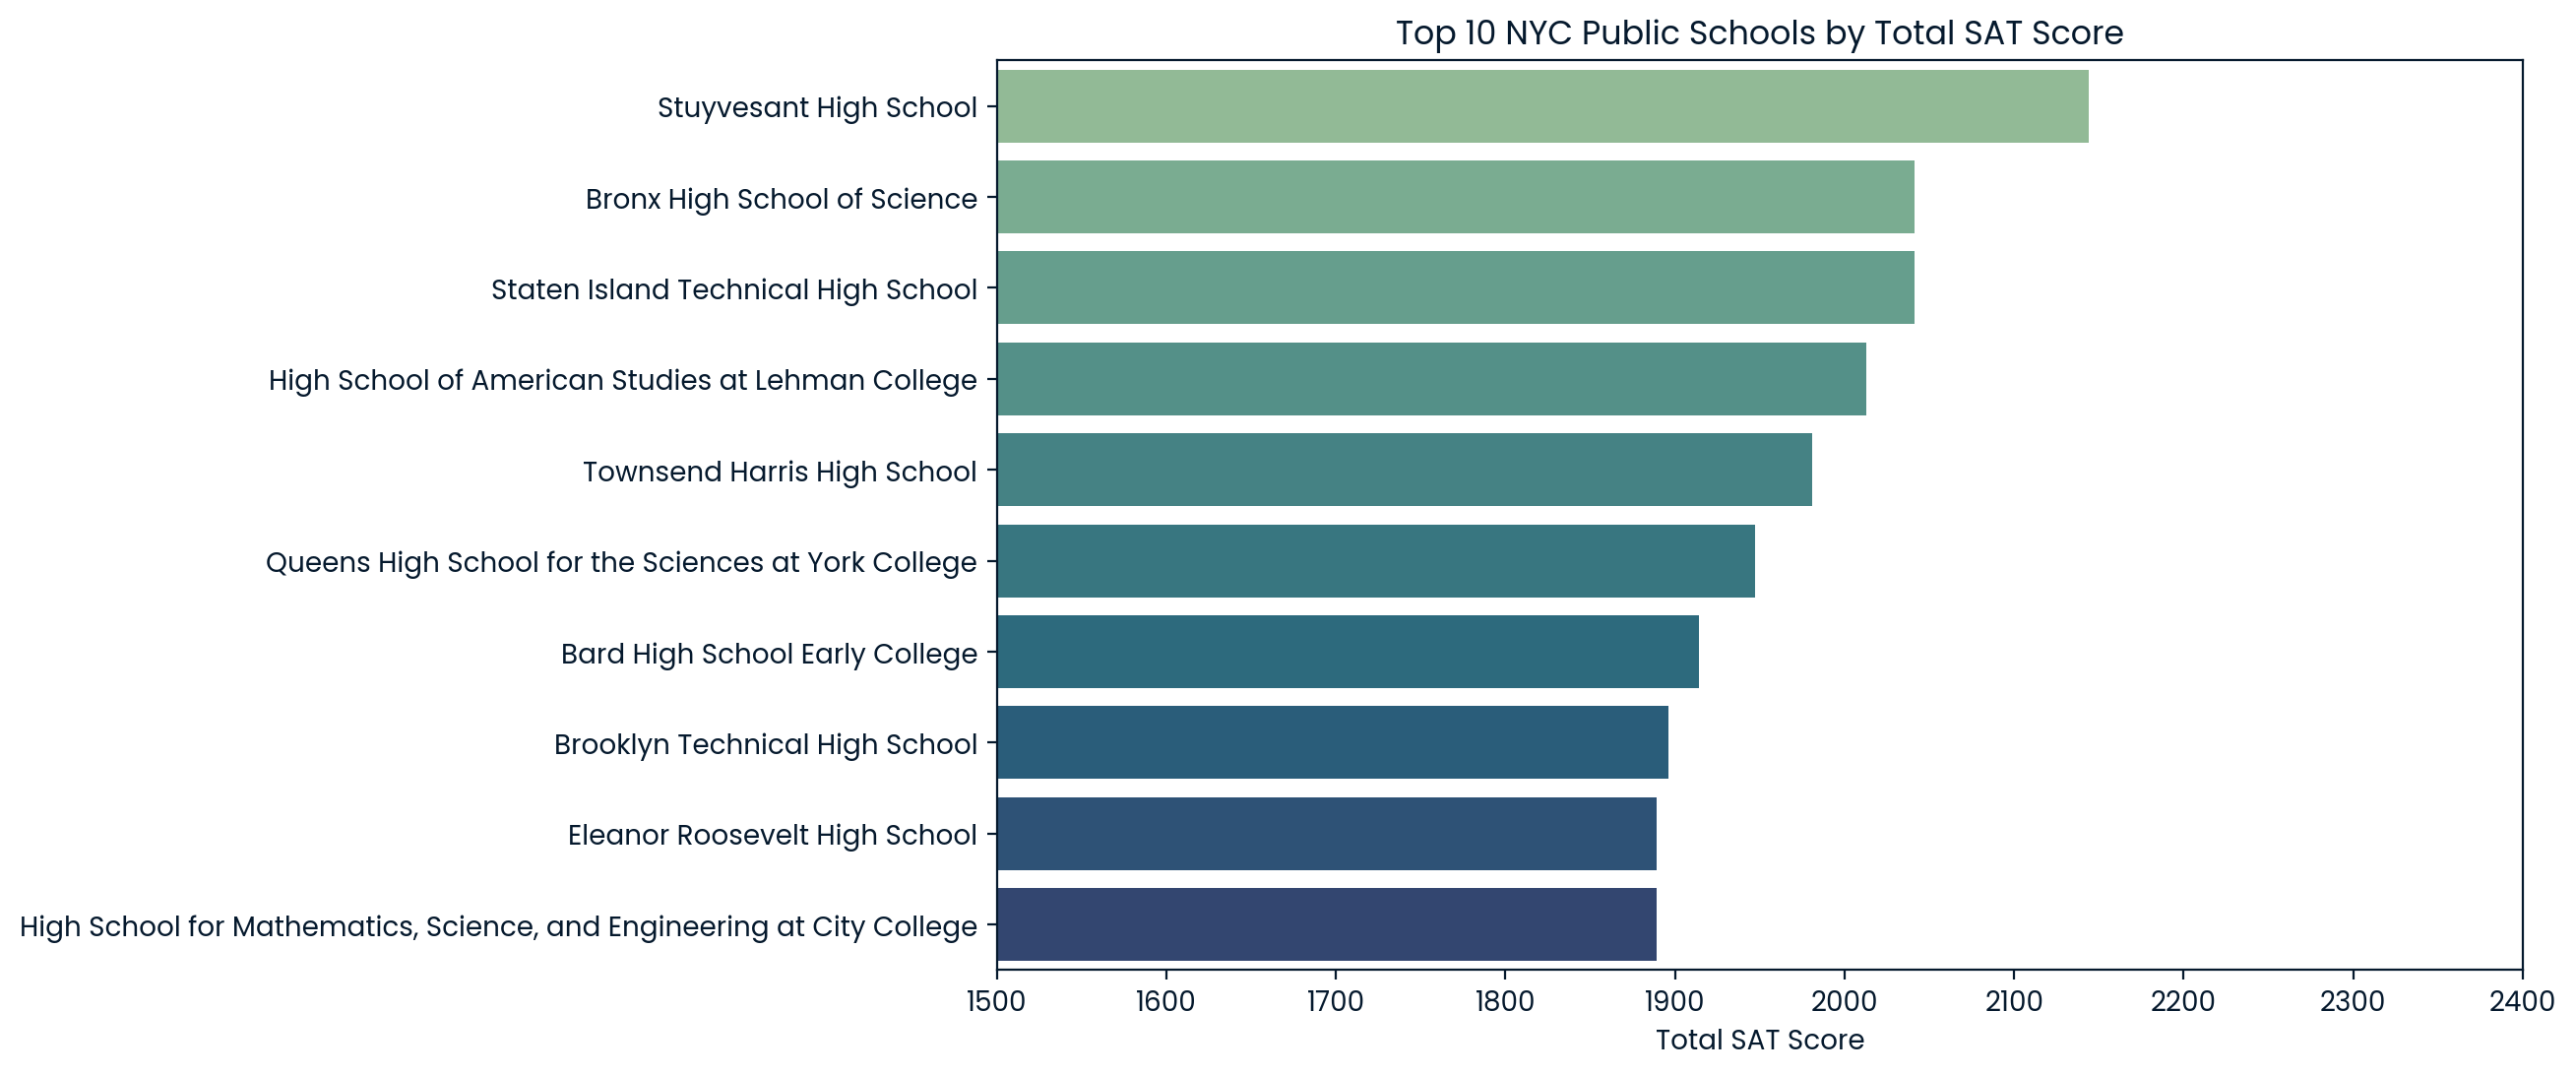

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_schools, x='total_SAT', y='school_name', palette='crest')
plt.title('Top 10 NYC Public Schools by Total SAT Score')
plt.xlabel('Total SAT Score')
plt.ylabel('') # Removes redundant axis label
plt.xlim(1500, 2400) # Assumes the 2400 max score scale
plt.show()